In [1]:
# Testing best visuals for global data with uncertainty

In [8]:
import xarray as xr
import matplotlib.pyplot as plt

In [51]:
da = xr.open_dataarray("/glade/work/awells/air_quality/CESM2/mortality/ozone/Global_mortality_200samples_CESM2_G6-1.5K_02_2035-2083.nc")
da2 = xr.open_dataarray("/glade/work/awells/air_quality/CESM2/mortality/ozone/Global_mortality_200samples_CESM2_SSP245_G6_02_2020-2083.nc")

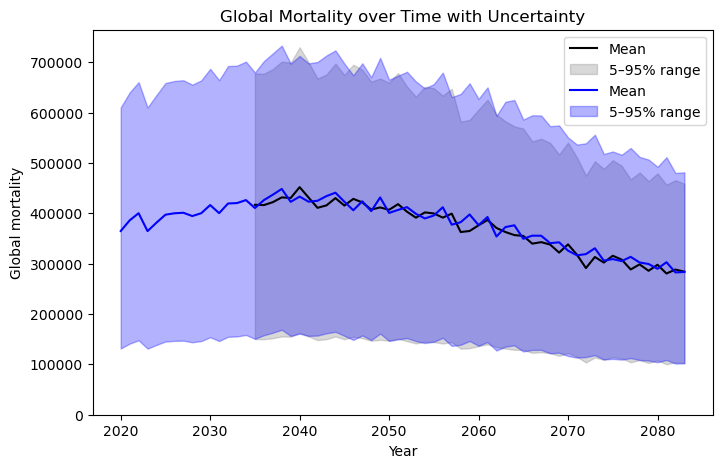

In [52]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

# Assuming da has dimensions ('year', 'samples')
mean = da.mean('samples')
p05 = da.quantile(0.05, 'samples')
p95 = da.quantile(0.95, 'samples')

mean2 = da2.mean('samples')
p052 = da2.quantile(0.05, 'samples')
p952 = da2.quantile(0.95, 'samples')

plt.figure(figsize=(8,5))
plt.plot(da['year'], mean, color='k', label='Mean')
plt.fill_between(da['year'], p05, p95, color='gray', alpha=0.3, label='5–95% range')
plt.plot(da2['year'], mean2, color='blue', label='Mean')
plt.fill_between(da2['year'], p052, p952, color='blue', alpha=0.3, label='5–95% range')
plt.ylim(bottom=0)
plt.xlabel('Year')
plt.ylabel('Global mortality')
plt.legend()
plt.title('Global Mortality over Time with Uncertainty')
plt.show()

In [53]:
test = da - da2

Text(0.5, 1.0, 'Distribution of Global Mortality by Decade')

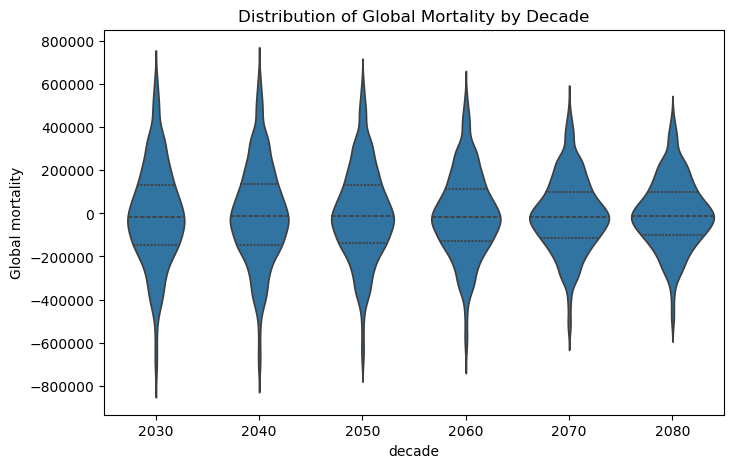

In [54]:
import seaborn as sns
import pandas as pd

df = test.to_dataframe(name='mortality').reset_index()
df['decade'] = (df['year'] // 10) * 10

plt.figure(figsize=(8,5))
sns.violinplot(x='decade', y='mortality', data=df, inner='quartile')
plt.ylabel('Global mortality')
plt.title('Distribution of Global Mortality by Decade')